# TrustCVValidator – IID Methods Overview

This notebook runs **all IID cross-validation methods** in TrustCV via
`TrustCVValidator` on the breast cancer dataset:

- HoldOut (stratified / non-stratified)
- KFold
- StratifiedKFold
- RepeatedKFold
- LOOCV
- LPOCV (on a subset, to keep runtime ok)
- MonteCarloCV
- BootstrapValidation

For each method we:

1. Construct a `TrustCVValidator`.
2. Call `.validate(model, X, y)`.
3. Print `val_result.summary()` (like the K-Fold example).
4. Collect `accuracy` and `roc_auc` in a table + bar plots.


-----

## 1 – Imports & data



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette(['#870052', '#FF876F', '#4F0433', '#EDF4F4'])

from trustcv import TrustCVValidator  # adjust path if needed

# Load data
X, y = load_breast_cancer(return_X_y=True)
print("X shape:", X.shape, "| y shape:", y.shape)

# Baseline model (sklearn pipeline)
base_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)
base_model


X shape: (569, 30) | y shape: (569,)


,steps,"[('standardscaler', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


## 2 – Helper to run one configuration

## 3 – Define all IID configurations

> ⚠️ If your implementation uses slightly different method strings (e.g. `"kfold"` instead of `"KFold"`), just change the `method` values below.

In [25]:
cv_configs = [
    # 1) HoldOut – non-stratified
    {
        "label": "HoldOut (no stratify)",
        "method": "HoldOut",
        "params": dict(
            test_size=0.2,
            stratify=None,
            random_state=42,
        ),
    },
    # 2) HoldOut – stratified
    {
        "label": "HoldOut (stratified)",
        "method": "HoldOut",
        "params": dict(
            test_size=0.2,
            stratify=True,          # or stratify=y in your API
            random_state=42,
        ),
    },
    # 3) KFold
    {
        "label": "KFold (5)",
        "method": "KFold",
        "params": dict(
            n_splits=5,
            #shuffle=True, # If you need a non‑shuffled StratifiedKFold equivalent, set shuffle=False here
            random_state=42,
        ),
    },
    # 4) StratifiedKFold
    {
        "label": "StratifiedKFold (5)",
        "method": "StratifiedKFold",
        "params": dict(
            n_splits=5,
            #shuffle=True,
            random_state=42,
        ),
    },
    # 5) RepeatedKFold
    {
        "label": "RepeatedKFold (stratified) (5x3)",
        "method": "RepeatedKFold",
        "params": dict(
            n_splits=5,
            n_repeats=3,
            random_state=42,
            stratify=True,     # or repeated_kfold_stratify=True
        ),
    },
    # 5) RepeatedKFold
    {
        "label": "RepeatedKFold (no stratify) (5x3)",
        "method": "RepeatedKFold",
        "params": dict(
            n_splits=5,
            n_repeats=3,
            random_state=42,
            stratify=False,     # or repeated_kfold_stratify=False
        ),
    },

    # 6) LOOCV
    {
        "label": "LOOCV",
        "method": "LOOCV",
        "params": dict(),
    },
    # 7) LPOCV – run on a subset to keep it fast
    {
        "label": "LPOCV (p=2, subset 60)",
        "method": "LPOCV",
        "params": dict(
            p=2,
            use_subset=True,   # custom flag we’ll handle
            subset_size=60,
        ),
    },

    # 8) MonteCarloCV
    {
        "label": "MonteCarlo (50x, 20% test)",
        "method": "MonteCarloCV",
        "params": dict(
            n_iterations=50,
            test_size=0.2,
            random_state=42,
        ),
    },
    # 9) BootstrapValidation
    {
        "label": "Bootstrap (100x, .632)",
        "method": "BootstrapValidation",
        "params": dict(
            n_iterations=100,
            test_size=0.2,
            random_state=42,
            bootstrap_estimator=".632",   # or "standard", ".632+"
        ),
    },
]
len(cv_configs)


10

##  4 – Collect *all* metrics from each CV method



In [26]:
import numpy as np
import pandas as pd

# Which metrics you want in the table (must match keys in val_result.mean_scores)
metrics = [
    "accuracy",
    "roc_auc",
    "sensitivity",
    "specificity",
    "precision",
    "recall",
    "f1",
]

rows = []

for cfg in cv_configs:
    method = cfg["method"]
    label = cfg["label"]
    params = cfg["params"].copy()   # copy so we can pop

    # Optional subset handling for LPOCV
    use_subset = params.pop("use_subset", False)
    subset_size = params.pop("subset_size", None)

    if use_subset and subset_size is not None:
        X_used, y_used = X[:subset_size], y[:subset_size]
    else:
        X_used, y_used = X, y

    print("\n" + "#" * 80)
    print(f"Running {label}  (method='{method}')")
    print("#" * 80)

    validator = TrustCVValidator(
        method=method,
        check_leakage=True,
        check_balance=True,
        # if you want to explicitly list metrics, uncomment:
        # metrics=metrics,
        return_confidence_intervals=True,
        ci_method="t-interval",
        ci_level=0.95,
        **params,
    )

    val_result = validator.validate(model=model, X=X_used, y=y_used)
    print(val_result.summary())  # pretty block like in your screenshot

    # ---- Build one row per CV method with ALL metrics ----
    row = {
        "cv_method": label,
        "method_arg": method,
        "n_samples_used": len(X_used),
    }

    for m in metrics:
        mean = val_result.mean_scores.get(m, np.nan)
        std  = val_result.std_scores.get(m, np.nan)
        ci   = val_result.confidence_intervals.get(m, (np.nan, np.nan))

        row[f"{m}_mean"]    = mean
        row[f"{m}_std"]     = std
        row[f"{m}_ci_low"]  = ci[0]
        row[f"{m}_ci_high"] = ci[1]

        # Optional: a formatted "mean ± std" string for direct reporting
        row[f"{m}_mean_std"] = f"{mean:.3f} ± {std:.3f}" if np.isfinite(mean) and np.isfinite(std) else "n/a"

    rows.append(row)

results_df = pd.DataFrame(rows)
results_df



################################################################################
Running HoldOut (no stratify)  (method='HoldOut')
################################################################################
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.965 +/- 0.000 [95% CI: n/a]
  roc_auc: 0.996 +/- 0.000 [95% CI: n/a]
  sensitivity: 0.986 +/- 0.000 [95% CI: n/a]
  specificity: 0.929 +/- 0.000 [95% CI: n/a]
  precision: 0.959 +/- 0.000 [95% CI: n/a]
  recall: 0.986 +/- 0.000 [95% CI: n/a]
  f1: 0.972 +/- 0.000 [95% CI: n/a]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED


################################################################################
Running HoldOut (stratified)  (method='HoldOut')
################################################################################
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  ac

,cv_method,method_arg,n_samples_used,accuracy_mean,accuracy_std,accuracy_ci_low,accuracy_ci_high,accuracy_mean_std,roc_auc_mean,roc_auc_std,...,recall_mean,recall_std,recall_ci_low,recall_ci_high,recall_mean_std,f1_mean,f1_std,f1_ci_low,f1_ci_high,f1_mean_std
0,HoldOut (no stratify),HoldOut,569,0.964602,0.000000,NaN,NaN,0.965 ± 0.000,0.995976,0.000000,...,0.985915,0.000000,NaN,NaN,0.986 ± 0.000,0.972222,0.000000,NaN,NaN,0.972 ± 0.000
1,HoldOut (stratified),HoldOut,569,0.956140,0.000000,NaN,NaN,0.956 ± 0.000,0.993882,0.000000,...,0.972222,0.000000,NaN,NaN,0.972 ± 0.000,0.965517,0.000000,NaN,NaN,0.966 ± 0.000
2,KFold (5),KFold,569,0.959587,0.007795,0.949908,0.969266,0.960 ± 0.008,0.987332,0.014289,...,0.969285,0.011668,0.954797,0.983772,0.969 ± 0.012,0.967765,0.006489,0.959708,0.975822,0.968 ± 0.006
3,StratifiedKFold (5),StratifiedKFold,569,0.956094,0.013796,0.938964,0.973224,0.956 ± 0.014,0.988548,0.009245,...,0.966471,0.030408,0.928715,1.004227,0.966 ± 0.030,0.965068,0.010840,0.951609,0.978527,0.965 ± 0.011
4,RepeatedKFold (stratified) (5x3),RepeatedKFold,569,0.958976,0.024808,0.945238,0.972714,0.959 ± 0.025,0.989498,0.009460,...,0.972900,0.025616,0.958714,0.987086,0.973 ± 0.026,0.967560,0.019481,0.956772,0.978348,0.968 ± 0.019
5,RepeatedKFold (no stratify) (5x3),RepeatedKFold,569,0.958961,0.018501,0.948715,0.969206,0.959 ± 0.019,0.988526,0.010319,...,0.970860,0.015898,0.962056,0.979664,0.971 ± 0.016,0.967153,0.015379,0.958637,0.975670,0.967 ± 0.015
6,LOOCV,LOOCV,569,0.961336,0.192963,0.945447,0.977225,0.961 ± 0.193,NaN,NaN,...,0.611599,0.487815,0.571432,0.651767,0.612 ± 0.488,0.611599,0.487815,0.571432,0.651767,0.612 ± 0.488
7,"LPOCV (p=2, subset 60)",LPOCV,60,0.933616,0.174635,0.925475,0.941757,0.934 ± 0.175,NaN,NaN,...,0.329944,0.467008,0.308172,0.351715,0.330 ± 0.467,0.327872,0.463648,0.306257,0.349487,0.328 ± 0.464
8,"MonteCarlo (50x, 20% test)",MonteCarloCV,569,0.960531,0.018854,0.955173,0.965889,0.961 ± 0.019,0.991201,0.007104,...,0.974221,0.020805,0.968308,0.980134,0.974 ± 0.021,0.968187,0.015824,0.963690,0.972684,0.968 ± 0.016
9,"Bootstrap (100x, .632)",BootstrapValidation,569,0.958739,0.013776,0.956818,0.960659,0.959 ± 0.014,0.989362,0.006043,...,0.974001,0.015419,0.971851,0.976151,0.974 ± 0.015,0.967261,0.011152,0.965706,0.968816,0.967 ± 0.011


> After this cell, you’ll see **nine K-Fold-style blocks**:
>  `=== Trustworthy Cross-Validation Results ===` with metrics and the **“Data Integrity Checks”** section for each method.

------

> This uses **`val_result.mean_scores`**, **`val_result.std_scores`**, and **`val_result.confidence_intervals`** directly – exactly the objects that produced the “mean ± std [95% CI]” lines you pasted.

For HoldOut you will naturally see `std = 0` and CI `n/a` (one split only) – the code just stores `NaN` for CI so the table stays consistent.

------

## 4.1. One organized table of all performance metrics

Now build a **clean, human-readable** view.

### 4.1.1 Wide table (one row per method, columns = metrics)

In [7]:
# Show all metrics columns (means + stds + CI) per method
cols_order = ["cv_method", "n_samples_used"]

for m in metrics:
    cols_order.extend([
        f"{m}_mean",
        f"{m}_std",
        f"{m}_ci_low",
        f"{m}_ci_high",
    ])

summary_full = results_df[cols_order].copy()
summary_full


,cv_method,n_samples_used,accuracy_mean,accuracy_std,accuracy_ci_low,accuracy_ci_high,roc_auc_mean,roc_auc_std,roc_auc_ci_low,roc_auc_ci_high,...,precision_ci_low,precision_ci_high,recall_mean,recall_std,recall_ci_low,recall_ci_high,f1_mean,f1_std,f1_ci_low,f1_ci_high
0,HoldOut (no stratify),569,0.964602,0.000000,NaN,NaN,0.995976,0.000000,NaN,NaN,...,NaN,NaN,0.985915,0.000000,NaN,NaN,0.972222,0.000000,NaN,NaN
1,HoldOut (stratified),569,0.956140,0.000000,NaN,NaN,0.993882,0.000000,NaN,NaN,...,NaN,NaN,0.972222,0.000000,NaN,NaN,0.965517,0.000000,NaN,NaN
2,KFold (5),569,0.959587,0.007795,0.949908,0.969266,0.987332,0.014289,0.969590,1.005074,...,0.950468,0.982386,0.969285,0.011668,0.954797,0.983772,0.967765,0.006489,0.959708,0.975822
3,StratifiedKFold (5),569,0.956094,0.013796,0.938964,0.973224,0.988548,0.009245,0.977069,1.000028,...,0.925996,1.004183,0.966471,0.030408,0.928715,1.004227,0.965068,0.010840,0.951609,0.978527
4,RepeatedKFold (stratified) (5x3),569,0.958976,0.024808,0.945238,0.972714,0.989498,0.009460,0.984259,0.994737,...,0.945916,0.980361,0.972900,0.025616,0.958714,0.987086,0.967560,0.019481,0.956772,0.978348
5,RepeatedKFold (no stratify) (5x3),569,0.958961,0.018501,0.948715,0.969206,0.988526,0.010319,0.982812,0.994241,...,0.951983,0.975409,0.970860,0.015898,0.962056,0.979664,0.967153,0.015379,0.958637,0.975670
6,LOOCV,569,0.961336,0.192963,0.945447,0.977225,NaN,NaN,NaN,NaN,...,0.571432,0.651767,0.611599,0.487815,0.571432,0.651767,0.611599,0.487815,0.571432,0.651767
7,"LPOCV (p=2, subset 60)",60,0.933616,0.174635,0.925475,0.941757,NaN,NaN,NaN,NaN,...,0.308172,0.351715,0.329944,0.467008,0.308172,0.351715,0.327872,0.463648,0.306257,0.349487
8,"MonteCarlo (50x, 20% test)",569,0.960531,0.018854,0.955173,0.965889,0.991201,0.007104,0.989182,0.993220,...,0.955988,0.969482,0.974221,0.020805,0.968308,0.980134,0.968187,0.015824,0.963690,0.972684
9,"Bootstrap (100x, .632)",569,0.958739,0.013776,0.956818,0.960659,0.989362,0.006043,0.988519,0.990204,...,0.958500,0.963322,0.974001,0.015419,0.971851,0.976151,0.967261,0.011152,0.965706,0.968816


This gives something like (example):

| cv_method             | n_samples_used | accuracy_mean | accuracy_std | accuracy_ci_low | accuracy_ci_high | roc_auc_mean | …    |
| --------------------- | -------------- | ------------- | ------------ | --------------- | ---------------- | ------------ | ---- |
| HoldOut (no stratify) | 569            | 0.965         | 0.000        | NaN             | NaN              | 0.996        | …    |
| HoldOut (stratified)  | 569            | 0.956         | 0.000        | NaN             | NaN              | 0.994        | …    |
| KFold (5)             | 569            | 0.960         | 0.008        | 0.950           | 0.969            | 0.987        | …    |
| StratifiedKFold (5)   | 569            | 0.956         | 0.014        | 0.939           | 0.973            | 0.989        | …    |
| …                     | …              | …             | …            | …               | …                | …            |      |

### 4.1.2 “Mean ± std” presentation in one cell

If you prefer a compact table you can show **formatted strings**:

In [21]:
cols_display = ["cv_method", "n_samples_used"]

for m in metrics:
    cols_display.append(f"{m}_mean_std")  # e.g. "0.960 ± 0.008"
    #cols_display.append(f"{m}_ci_low_high")  # e.g. "(0.940, 0.980)"

summary_display = results_df[cols_display].copy()
summary_display


,cv_method,n_samples_used,accuracy_mean_std,roc_auc_mean_std,sensitivity_mean_std,specificity_mean_std,precision_mean_std,recall_mean_std,f1_mean_std
0,HoldOut (no stratify),569,0.965 ± 0.000,0.996 ± 0.000,0.986 ± 0.000,0.929 ± 0.000,0.959 ± 0.000,0.986 ± 0.000,0.972 ± 0.000
1,HoldOut (stratified),569,0.956 ± 0.000,0.994 ± 0.000,0.972 ± 0.000,0.929 ± 0.000,0.959 ± 0.000,0.972 ± 0.000,0.966 ± 0.000
2,KFold (5),569,0.960 ± 0.008,0.987 ± 0.014,0.969 ± 0.012,0.944 ± 0.020,0.966 ± 0.013,0.969 ± 0.012,0.968 ± 0.006
3,StratifiedKFold (5),569,0.956 ± 0.014,0.989 ± 0.009,0.966 ± 0.030,0.939 ± 0.056,0.965 ± 0.031,0.966 ± 0.030,0.965 ± 0.011
4,RepeatedKFold (stratified) (5x3),569,0.959 ± 0.025,0.989 ± 0.009,0.973 ± 0.026,0.936 ± 0.055,0.963 ± 0.031,0.973 ± 0.026,0.968 ± 0.019
5,RepeatedKFold (no stratify) (5x3),569,0.959 ± 0.019,0.989 ± 0.010,0.971 ± 0.016,0.939 ± 0.035,0.964 ± 0.021,0.971 ± 0.016,0.967 ± 0.015
6,LOOCV,569,0.961 ± 0.193,n/a,0.612 ± 0.488,0.350 ± 0.477,0.612 ± 0.488,0.612 ± 0.488,0.612 ± 0.488
7,"LPOCV (p=2, subset 60)",60,0.934 ± 0.175,n/a,0.330 ± 0.467,0.915 ± 0.255,0.330 ± 0.467,0.330 ± 0.467,0.328 ± 0.464
8,"MonteCarlo (50x, 20% test)",569,0.961 ± 0.019,0.991 ± 0.007,0.974 ± 0.021,0.939 ± 0.038,0.963 ± 0.024,0.974 ± 0.021,0.968 ± 0.016
9,"Bootstrap (100x, .632)",569,0.959 ± 0.014,0.989 ± 0.006,0.974 ± 0.015,0.933 ± 0.028,0.961 ± 0.017,0.974 ± 0.015,0.967 ± 0.011


Example row:

| cv_method | n_samples_used | accuracy_mean_std | roc_auc_mean_std | sensitivity_mean_std | …    |
| --------- | -------------- | ----------------- | ---------------- | -------------------- | ---- |
| KFold (5) | 569            | 0.960 ± 0.008     | 0.987 ± 0.014    | 0.969 ± 0.012        | …    |

This is very close to your textual summary, but **organized side-by-side** for all methods.

------





## 6 – Plot: Accuracy ± CI for all methods

Below are **two plotting snippets**:

1. **Accuracy ± CI** for each method (using the 95% CI from `TrustCVValidator`).
2. **Accuracy ± std** for each method (classic “mean ± std” error bars).

They assume you ran the loop I gave you earlier and you have `results_df` with columns:

- `"cv_method"`
- `"accuracy_mean"`, `"accuracy_std"`,
- `"accuracy_ci_low"`, `"accuracy_ci_high"`,
   (and similar for roc_auc, etc.)

------

### 1. Accuracy ± 95% CI for all methods

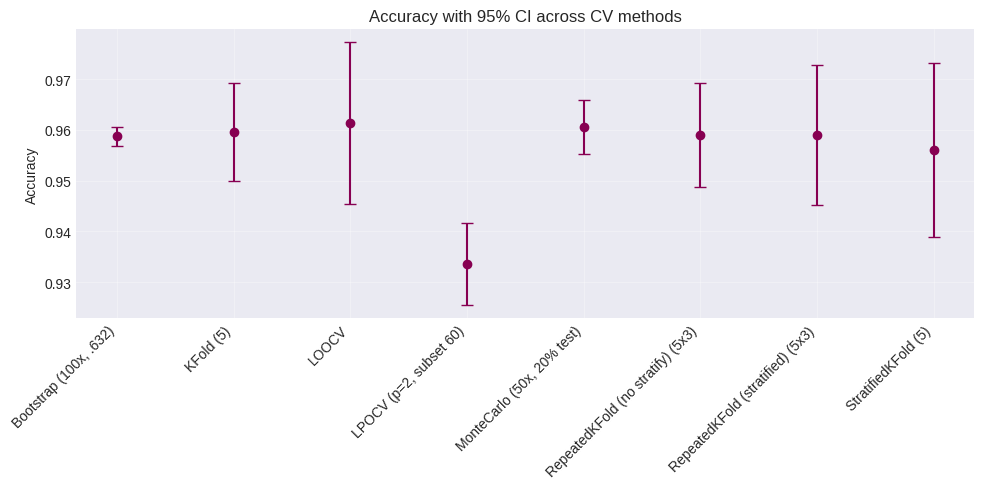

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Sort methods in a consistent order
summary_df = results_df.sort_values("cv_method").reset_index(drop=True)

# Drop methods where CI is NaN (e.g. HoldOut with one split)
mask_ci_ok = summary_df["accuracy_ci_low"].notna() & summary_df["accuracy_ci_high"].notna()
summary_ci = summary_df[mask_ci_ok].copy()

x = np.arange(len(summary_ci))
acc = summary_ci["accuracy_mean"].values
ci_low = summary_ci["accuracy_ci_low"].values
ci_high = summary_ci["accuracy_ci_high"].values

# Asymmetric error: distance from mean to CI bounds
yerr = np.vstack([acc - ci_low, ci_high - acc])

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x,
    acc,
    yerr=yerr,
    fmt="o",
    capsize=4,
    linestyle="none",
)

ax.set_xticks(x)
ax.set_xticklabels(summary_ci["cv_method"], rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy with 95% CI across CV methods")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Notes**

- This skips rows where CI is `NaN` (e.g. `HoldOut` with a single split).
- The error bars are **asymmetric**, using your real lower/upper CI.

If you **want to keep HoldOut in the figure**, you can fill missing CIs with 0-width error bars:

```python
summary_df["accuracy_ci_low"]  = summary_df["accuracy_ci_low"].fillna(summary_df["accuracy_mean"])
summary_df["accuracy_ci_high"] = summary_df["accuracy_ci_high"].fillna(summary_df["accuracy_mean"])
# then use summary_df instead of summary_ci above
```

------

## 2. Accuracy ± std for all methods (mean ± std)

Sometimes it’s clearer to just show the **mean ± std** (what your summary block prints as `0.960 +/- 0.008`).

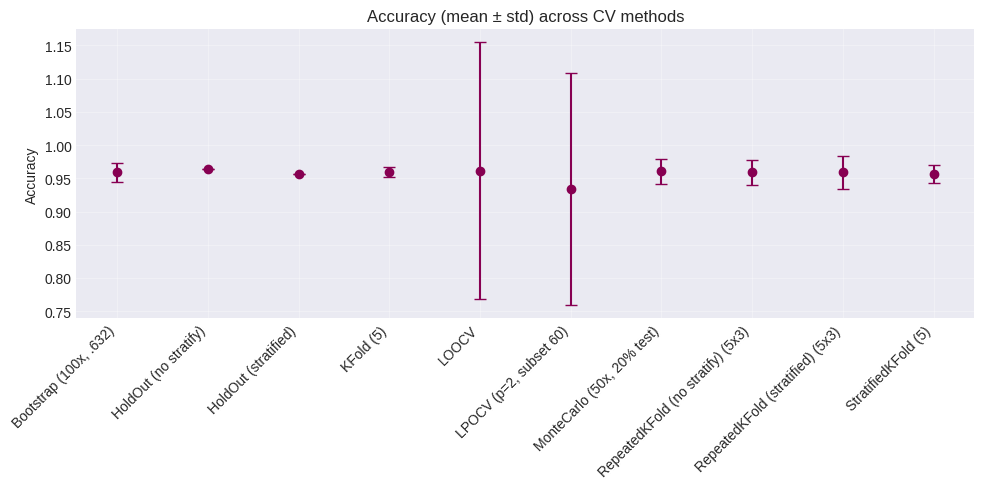

In [17]:
summary_std = results_df.sort_values("cv_method").reset_index(drop=True)

x = np.arange(len(summary_std))
acc = summary_std["accuracy_mean"].values
std = summary_std["accuracy_std"].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x,
    acc,
    yerr=std,
    fmt="o",
    capsize=4,
    linestyle="none",
)

ax.set_xticks(x)
ax.set_xticklabels(summary_std["cv_method"], rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy (mean ± std) across CV methods")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
